# 基础概念题（必考）
1. 写出马尔可夫决策过程（MDP）的五元组，并解释每个元素
答案：(S,A,P,R,γ) 
  - S ：状态空间
  - A ：动作空间
  - P(s′∣s,a) ：状态转移概率
  - R(s,a,s′) ：奖励函数
  - γ∈[0,1) ：折扣因子

# 贝尔曼期望方程 vs 贝尔曼最优方程



|                | **贝尔曼<font color='red'>期望</font>方程**                                                                                   | **贝尔曼<font color='red'>最优</font>方程**                                                                   |
| :------------- | :-------------------------------------------------------------------------------------------- | :---------------------------------------------------------------------------- |
| **状态价值函数 $V$** | $V^\pi(s) = \sum_a \pi(a\|s) \sum_{s'} P(s'\|s,a)\left[R + \gamma V^\pi(s')\right]$           | $V^*(s) = \max_a \sum_{s'} P(s'\|s,a)\left[R + \gamma V^*(s')\right]$         |
| **动作价值函数 $Q$** | $Q^\pi(s,a) = \sum_{s'} P(s'\|s,a)\left[R + \gamma \sum_{a'} \pi(a'\|s') Q^\pi(s',a')\right]$ | $Q^*(s,a) = \sum_{s'} P(s'\|s,a)\left[R + \gamma \max_{a'} Q^*(s',a')\right]$ |
| **核心操作**       | 对动作求**期望**（按策略 $\pi$ 加权平均）                                                                    | 对动作求**最大值**（选最优动作）                                                            |
| **含义**         | 描述**给定策略 $\pi$** 下的价值                                                                         | 描述**最优策略 $\pi^*$** 下的价值                                                       |
| **求解算法**       | 策略评估（Policy Evaluation）                                                                       | 值迭代（Value Iteration）/ 策略迭代（Policy Iteration）                                  |
| **方程性质**       | 线性方程组（对固定 $\pi$）                                                                              | 非线性方程组（因含 $\max$ 算子）                                                          |


In [ ]:
贝尔曼期望方程:          贝尔曼最优方程:
    E[·] 期望                max[·] 取最大
     ↓                        ↓
  "按策略随机选"            "按最优确定性选"
     ↓                        ↓
  V^π(s) ───────────→      V*(s) ≥ V^π(s)
  (任何策略的价值)          (所有策略中价值最大)
    
    
一句话记忆
期望方程 = "跟着当前策略走，平均下来值多少"（E_π）
最优方程 = "每一步都选最好的，最多能值多少"（max_a）

#  探索（Exploration）与利用（Exploitation）的权衡方法
- ϵ -greedy
- Softmax / Boltzmann 探索
- Upper Confidence Bound (UCB)
- Thompson Sampling
- 添加噪声（如 Ornstein-Uhlenbeck for DDPG）

# 折扣因子 γ 的作用
- γ→0 ：短视，**只关注即时奖励**
- γ→1 ：<font color='red'>远视，但可能导致方差爆炸、训练不稳定</font>
- <font color='red'>实际常用 0.95~0.99</font>

# 算法原理与对比（高频）
##  Q-learning vs SARSA

|          | Q-learning            | SARSA                       |
| :------- | :-------------------- | :-------------------------- |
| **类型**   | **Off**-policy            | **On**-policy                   |
| **更新目标** | $\max_{a'} Q(s', a')$ | $Q(s', a')$ 其中 $a'$ 由当前策略选出 |
| **行为**   | **更激进，可能走悬崖**             | **更保守，遵循当前策略 **                 |
| **收敛**   | 收敛到 $Q^*$             | 收敛到当前策略的 $Q^\pi$            |

## DQN 的三大改进（解决什么问题）
- Experience Replay：打破样本相关性，提高数据效率
- Target Network：减少目标值波动，提高稳定性
- Double DQN / Dueling DQN / Prioritized Replay：<font color='red'>进一步解决 Q 值过估计 / 学习效率问题</font>

## Actor-Critic 中 Actor 和 Critic 分别做什么？
- Actor：策略网络 $π_θ(a∣s)$ ，决定动作
- Critic：价值网络 $V_ϕ(s)$  或 $Q_ϕ(s,a)$ ，评估状态/动作价值，<font color='red'>为 Actor 提供低方差的优势估计</font>


## TRPO 的核心思想，PPO 如何简化 TRPO？
- TRPO：用 KL 散度约束策略更新步长，保证单调提升；<font color='blue'>但需计算 Fisher 信息矩阵，用共轭梯度法，工程复杂</font>
- PPO：<font color='red'>用 Clipped Surrogate Objective 替代 KL 约束：</font>
$L^{CLIP}=E[min(ρA,clip(ρ,1−ϵ,1+ϵ)A)]$

  - <font color='red'>实现简单，效果相当</font>


## On-policy vs Off-policy 的区别及代表算法

|          | On-policy             | Off-policy                 |
| :------- | :-------------------- | :------------------------- |
| **定义**   | 只能用当前策略采集的数据更新        | 可以用旧策略或其他策略的数据更新           |
| **代表**   | SARSA, A2C, PPO, TRPO | Q-learning, DQN, DDPG, SAC |
| **样本效率** | 低（<font color='red'>用完即弃</font>）               | 高（<font color='red'>经验回放复用</font>）                  |


# 数学推导题（硬核）

## 推导策略梯度定理（Policy Gradient Theorem）

In [1]:
from IPython.display import Image

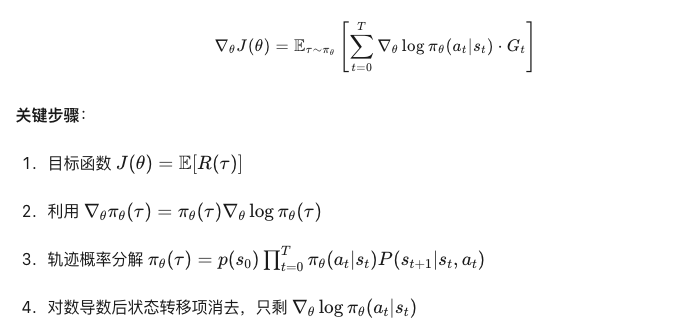

In [2]:
Image(filename='./Image/pgt.png')

## 推导 PPO 的 Clipped Objective 为什么能防止策略崩溃

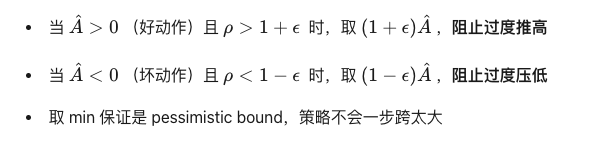

In [3]:
Image(filename='./Image/ppo_clip.png')

## 写出 GAE（Generalized Advantage Estimation）公式

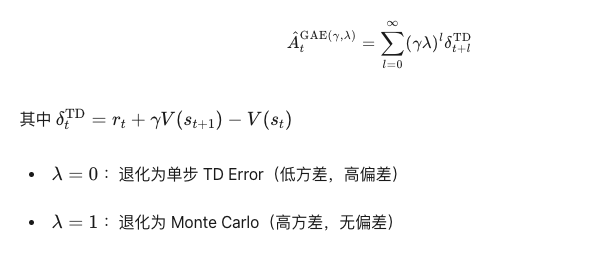

In [4]:
Image(filename='./Image/gae.png')

# LLM + RL 专题（现代面试重点）

## RLHF 中 PPO 的完整损失函数包含哪些项？

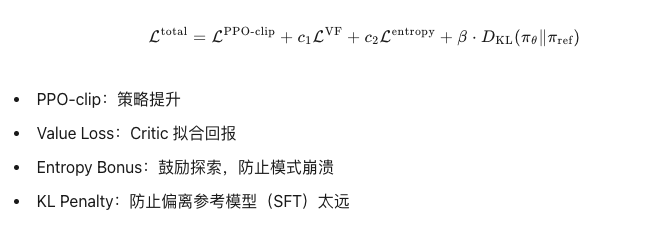

In [5]:
Image(filename='./Image/ppo_loss.png')

## DPO 相比 RLHF-PPO 的优势和劣势

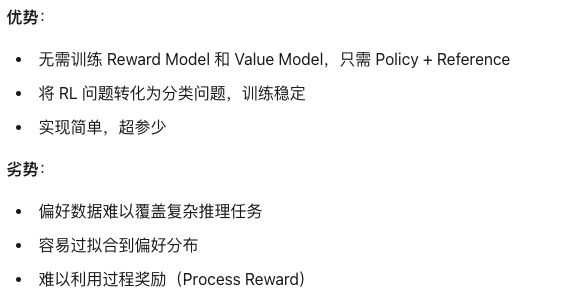

In [6]:
Image(filename='./Image/dpo_vs_ppo.png')

## GRPO 为什么不需要 Value Network？

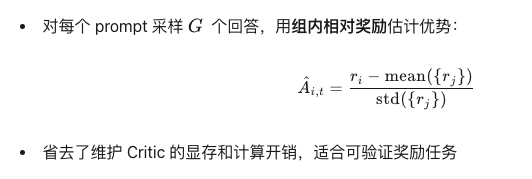

In [8]:
Image(filename='./Image/grpo_group.png')

## 为什么 RLVR 中低概率 token 的梯度范数更大？

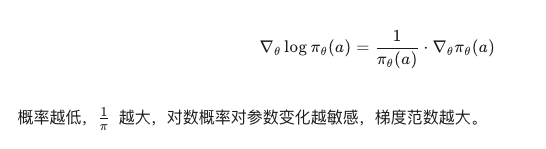

In [9]:
Image(filename='./Image/token_f.png')

# 编程与工程题
## 手写 Q-learning 更新代码

In [ ]:
def q_learning_update(Q, s, a, r, s_next, alpha=0.1, gamma=0.99):
    max_q_next = max(Q[s_next].values()) if s_next in Q else 0
    td_target = r + gamma * max_q_next
    td_error = td_target - Q[s][a]
    Q[s][a] += alpha * td_error
    return Q

## 计算 Advantage 的 GAE 实现

In [ ]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = torch.zeros_like(rewards)
    gae = 0
    for t in reversed(range(len(rewards))):
        if dones[t]:
            delta = rewards[t] - values[t]
            gae = delta
        else:
            delta = rewards[t] + gamma * values[t+1] - values[t]
            gae = delta + gamma * lam * gae
        advantages[t] = gae
    return advantages

## PPO 的 Ratio Clip 实现

In [ ]:
ratio = torch.exp(new_log_probs - old_log_probs)
surrogate1 = ratio * advantages
surrogate2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages
loss = -torch.min(surrogate1, surrogate2).mean()

## 解释 clip_grad_norm_ 在 RL 中的作用

- RL 中梯度因 ρ×A  的乘积可能无界爆炸
- clip_grad_norm_(..., max_norm=1.0) 将总梯度缩放到半径为 1 的球内
- 保留方向，限制步长，防止策略一步跨太大导致崩溃

# 开放性问题（考察深度）
##  为什么 LLM 的 RL 训练比游戏 RL 更难？
  - 动作空间巨大（词汇表几万到几十万）
  - 奖励稀疏且延迟（只有序列结束才有奖励）
  - 序列长度可变，信用分配困难
  - 策略空间非凸，训练不稳定
##  如果 PPO 训练后模型出现"模式崩溃"（只输出固定句式），可能的原因？
  - KL 惩罚系数 β  太小，模型偏离参考模型太远
  - Entropy bonus 太小，探索不足
  - 奖励设计有漏洞（Reward Hacking）
  - 学习率过大，梯度裁剪不够
##  如何在不增加显存的情况下提升 RL 样本效率？
  - GRPO：去掉 Value Network，用组内基线
  - 经验回放变体：如 V-trace, IMPALA 的 off-policy 修正
  - 数据增广：对 prompt/response 做语义保持的变换